In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=56
)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
import torch
import torch.nn as nn

In [12]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)

In [13]:
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)

In [14]:
y_train_tesnors=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

In [15]:
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [16]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tesnors)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [18]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [19]:
### Deeplearning

##Define ANN Model

class ANN(nn.Module):
    def __init__(self):
        super (ANN,self).__init__()

        self.model=nn.Sequential(
        #1st hidden layer
            nn.Linear(X_train.shape[1],6),

            nn.ReLU(),


        #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

        #output layer
            nn.Linear(6,1),
    )

    def forward(self,x):
        return self.model(x)
    
    

In [20]:
import torch.optim as optim

model=ANN()




# loss,optimizer define karte hain iss step main in creating model
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [24]:
# train the ann
train_losses=[]
validation_losses=[]
epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0


    for xb,yb in train_loader:
        # xb=features of 1 batch
        # yb =labels of 1 batch

        optimizer.zero_grad()

        outputs=model(xb) # forward prop. predicted outputs for this batch
        loss=criterion(outputs,yb)

        loss.backward()  #back pro..  compute gradients

        optimizer.step()  # params updatest i.e, weights and bias
  

        running_loss+=loss.item()  # here loss is tensor so swe are converting it to py float

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)



    #validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in test_loader:

            outputs=model(xb) # forward prop. predicted outputs for this batch
            loss=criterion(outputs,yb)

        # loss.backward()  #back pro..  compute gradients

        # optimizer.step()  # params updatest i.e, weights and bias
  

            running_val_loss+=loss # here loss is tensor so swe are converting it to py float

    epoch_test_loss=running_val_loss/len(test_loader)
    validation_losses.append(epoch_test_loss)

    print(f"epoc ${epoch+1}/{epochs} ==> train loss= ${epoch_train_loss} & val loss= {epoch_test_loss}")



epoc $1/100 ==> train loss= $28.446565639972686 & val loss= 27.43202781677246
epoc $2/100 ==> train loss= $27.84837576945623 & val loss= 28.151159286499023
epoc $3/100 ==> train loss= $27.38100519279639 & val loss= 26.609962463378906
epoc $4/100 ==> train loss= $27.07988710006078 & val loss= 25.803071975708008
epoc $5/100 ==> train loss= $26.518068130811056 & val loss= 25.649805068969727
epoc $6/100 ==> train loss= $26.0284747838974 & val loss= 25.18556785583496
epoc $7/100 ==> train loss= $25.648875097433727 & val loss= 25.278078079223633
epoc $8/100 ==> train loss= $25.46129483381907 & val loss= 24.453777313232422
epoc $9/100 ==> train loss= $25.04060608545939 & val loss= 24.244300842285156
epoc $10/100 ==> train loss= $24.766846764087678 & val loss= 24.069194793701172
epoc $11/100 ==> train loss= $24.55362673997879 & val loss= 23.572935104370117
epoc $12/100 ==> train loss= $24.11447306871414 & val loss= 23.558765411376953
epoc $13/100 ==> train loss= $23.982982246081033 & val loss=

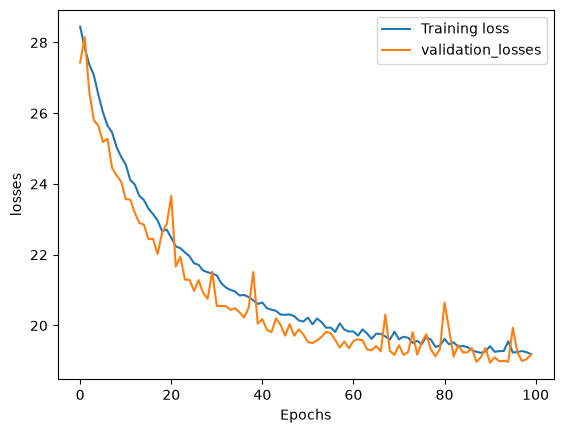

In [28]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "train_loss":train_losses,
    "val_loss":validation_losses
})

plt.plot(loss_df["train_loss"],label="Training loss")
plt.plot(loss_df["val_loss"],label="validation_losses")

plt.xlabel("Epochs")
plt.ylabel("losses")

plt.legend()

In [26]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.3 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.3 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.3 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.3/9.3 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.3 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.3 MB 1.0 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.3 MB 1.0 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.3 MB 882.6 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/9.3 MB 873.4 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/9.3 MB 873.4 kB/s eta 0:00:09
   ---------- ------